# Step 2 - Exploratory Data Analysis

Demand patterns by site, cement type and period. Weather correlation. Planned-vs-actual censoring analysis.

In [1]:
import sys
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# Add the src folder to Python's search path
sys.path.append(str(PROJECT_ROOT / "src"))

print("Project Root:", PROJECT_ROOT)

Project Root: c:\Users\Olami\OneDrive\Documents\DATASCIENCEPROJECT\MIG_Cement_Demand_Forecasting


## 2 - Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mig_cement.config import settings
from mig_cement.data import load

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

print("Imports successful!")

Imports successful!


## 3  Load the cleaned dataset

In [3]:
panel = load.load_panel()

print(f"Dataset Shape: {panel.shape}")

panel.head()

Dataset Shape: (32880, 13)


,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity,region,behavior
0,2022-01-01,SITE_001,CEM_II,43.18,34.54,52.56,45.83,63.85,3.40,-3.10,448,North,aggressive
1,2022-01-02,SITE_001,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,448,North,aggressive
2,2022-01-03,SITE_001,CEM_III,38.69,38.69,38.56,47.19,47.06,2.64,6.40,448,North,aggressive
3,2022-01-04,SITE_001,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,448,North,aggressive
4,2022-01-05,SITE_001,CEM_III,56.88,47.04,32.64,14.40,0.00,2.69,8.97,448,North,aggressive


## INITIAL DATA ASSESMENT 

In [4]:

# ==========================================

# Ensure the date column is in datetime format
panel["date"] = pd.to_datetime(panel["date"])

summary = {
    "Rows": len(panel),
    "Columns": panel.shape[1],
    "Date Range": f"{panel['date'].min().date()} to {panel['date'].max().date()}",
    "Sites": panel["site_id"].nunique(),
    "Regions": panel["region"].nunique(),
    "Cement Types": panel["cement_type"].nunique(),
    "Missing Values": int(panel.isna().sum().sum()),
    "Duplicate Rows": int(panel.duplicated().sum())
}

display(
    pd.DataFrame.from_dict(summary, orient="index", columns=["Value"])
)

,Value
Rows,32880
Columns,13
Date Range,2022-01-01 to 2024-12-31
Sites,30
Regions,4
Cement Types,3
Missing Values,0
Duplicate Rows,0


## Exploratory Data Analysis

## Descriptive statistics

In [14]:
summary_stats = (
    panel[ [
            "planned_pour_tonnes",
            "consumed_tonnes",
            "opening_inventory_tonnes",
            "deliveries_tonnes",
            "closing_inventory_tonnes",
            "rain_mm",
            "avg_temp_c" ]]
    .describe()
    .T
    .round(2))

display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
planned_pour_tonnes,32880.0,30.70,19.49,0.0,12.83,33.46,47.61,69.98
consumed_tonnes,32880.0,23.72,16.85,0.0,10.71,19.72,36.49,69.97
opening_inventory_tonnes,32880.0,3066.68,5586.03,0.0,1.28,50.71,3298.52,20646.18
deliveries_tonnes,32880.0,29.29,12.33,0.0,19.30,29.49,39.75,50.00
closing_inventory_tonnes,32880.0,3072.25,5593.02,0.0,1.27,50.66,3312.06,20658.87
rain_mm,32880.0,5.01,5.00,0.0,1.44,3.47,6.97,50.00
avg_temp_c,32880.0,10.09,8.52,-5.0,3.34,9.99,16.70,35.00


Descriptive statistics were generated to summarise the numerical variables and understand their overall characteristics. The results show considerable variation in cement consumption, inventory levels, and weather conditions across the dataset.

In [15]:
panel.groupby("site_id")["opening_inventory_tonnes"].mean().sort_values(ascending=False)

site_id
SITE_029    10368.471962
SITE_019    10286.764827
SITE_015    10263.443394
SITE_004    10236.611323
SITE_012    10152.297710
SITE_009     9998.251423
SITE_027     9857.255876
SITE_002     9854.975703
SITE_023     9534.154991
SITE_024      253.696232
SITE_028      211.543741
SITE_016      189.379425
SITE_014      183.679398
SITE_013      179.212965
SITE_026      152.376588
SITE_006       88.707819
SITE_003       17.127847
SITE_030       16.119571
SITE_017       14.667646
SITE_018       14.570456
SITE_001       14.180739
SITE_022       13.382746
SITE_010       13.291807
SITE_025       13.217801
SITE_007       13.081031
SITE_011       12.377628
SITE_005       12.333440
SITE_008       12.248750
SITE_021       11.604005
SITE_020       11.439297
Name: opening_inventory_tonnes, dtype: float64

## Numerical Features

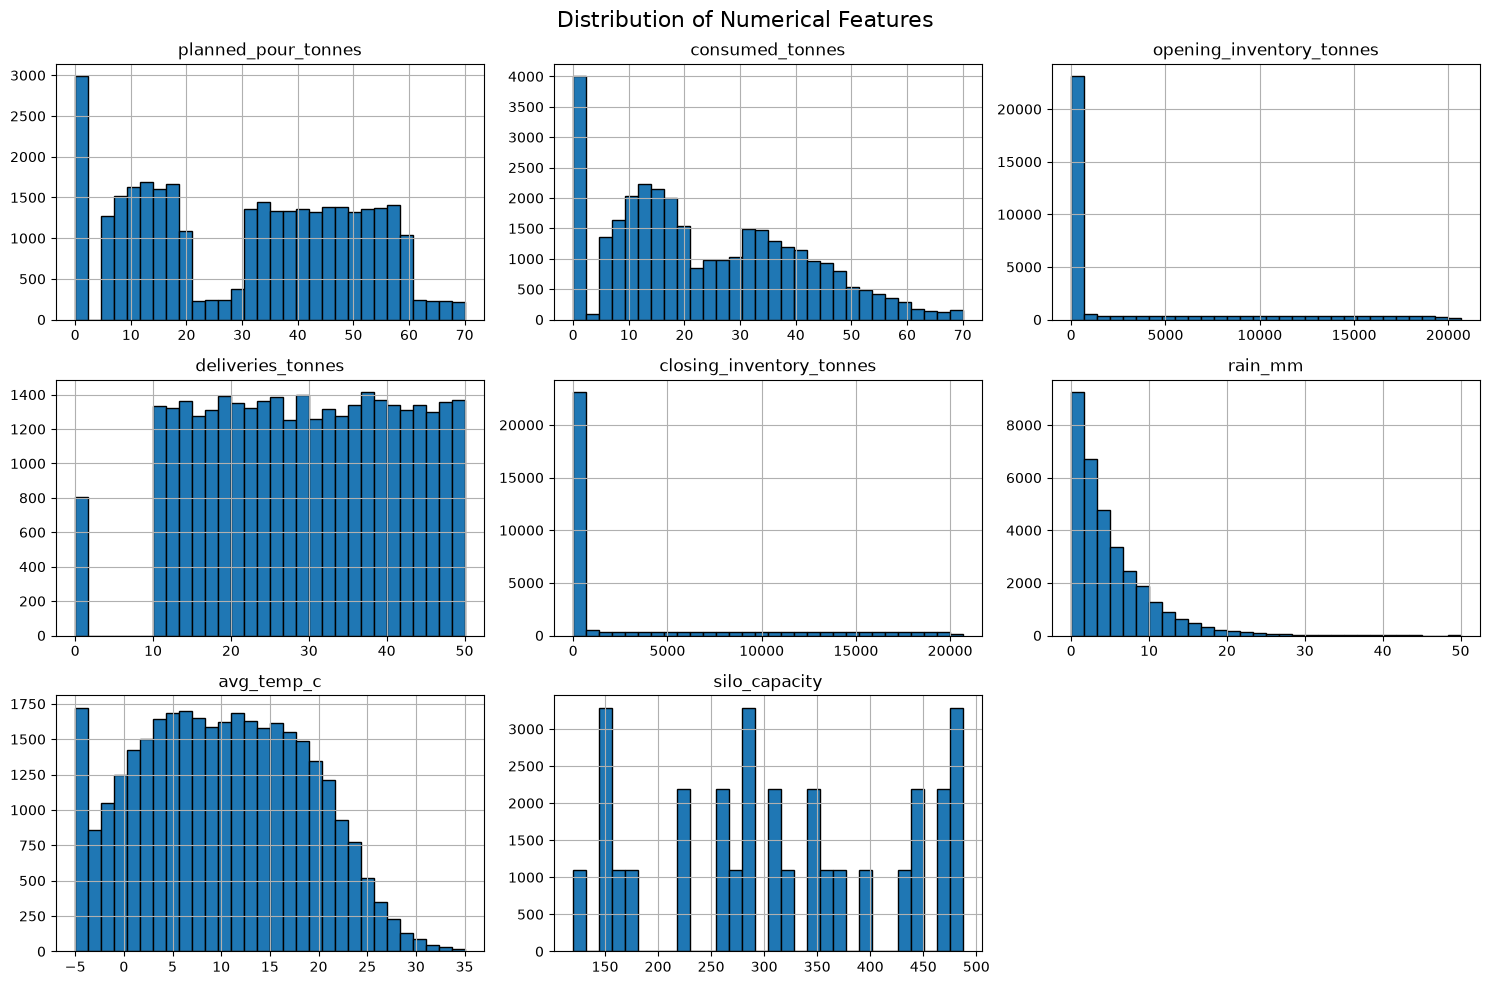

In [5]:
# ==========================================
# Distribution of Numerical Features
# ==========================================

numerical_cols = panel.select_dtypes(include=["number"]).columns

panel[numerical_cols].hist(
    figsize=(15, 10),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

## Target Variable Analysis

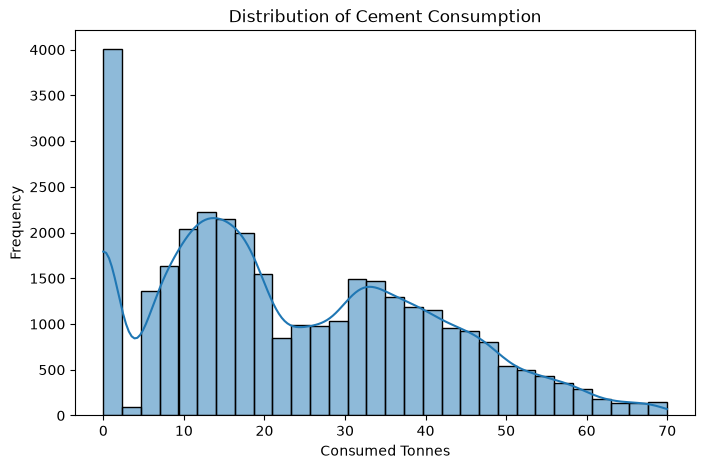

In [6]:
# ==========================================
# Distribution of Cement Consumption
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(
    panel["consumed_tonnes"],
    bins=30,
    kde=True
)

plt.title("Distribution of Cement Consumption")
plt.xlabel("Consumed Tonnes")
plt.ylabel("Frequency")

plt.show()

The target variable was analysed to understand the overall pattern of daily cement demand. Most observations fall within the low to moderate consumption range, while high-consumption days occur less frequently.

## Time Series Trend

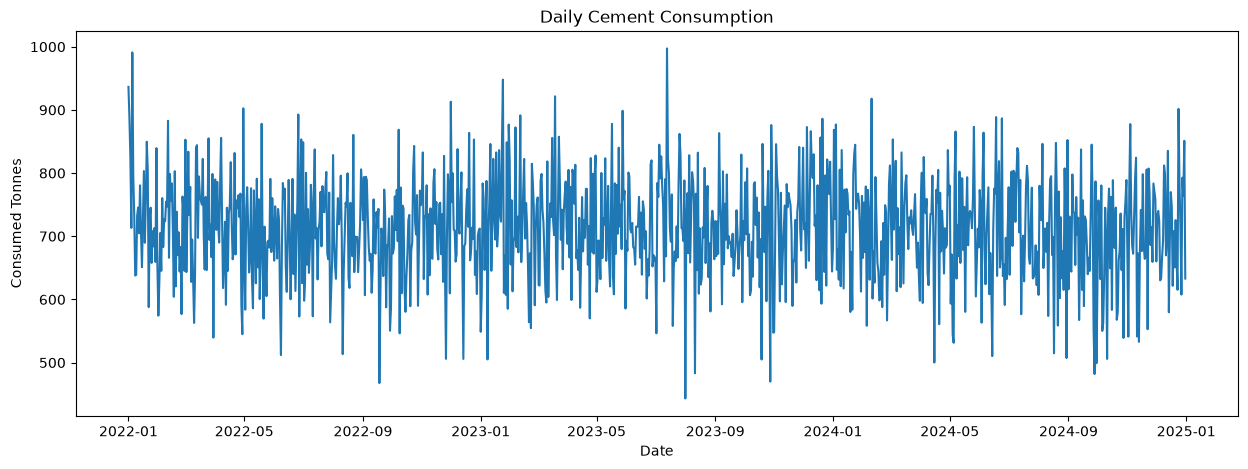

In [7]:
# ==========================================
# Daily Cement Consumption
# ==========================================

daily = (
    panel
    .groupby("date")["consumed_tonnes"]
    .sum()
)

plt.figure(figsize=(15,5))

plt.plot(daily.index, daily.values)

plt.title("Daily Cement Consumption")
plt.xlabel("Date")
plt.ylabel("Consumed Tonnes")

plt.show()

Daily cement consumption was plotted to identify temporal patterns and fluctuations. The results show substantial day-to-day variation but no obvious long-term increasing or decreasing trend.

## Monthly Trend

C:\Users\Olami\AppData\Local\Temp\ipykernel_23156\3060248904.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["consumed_tonnes"]


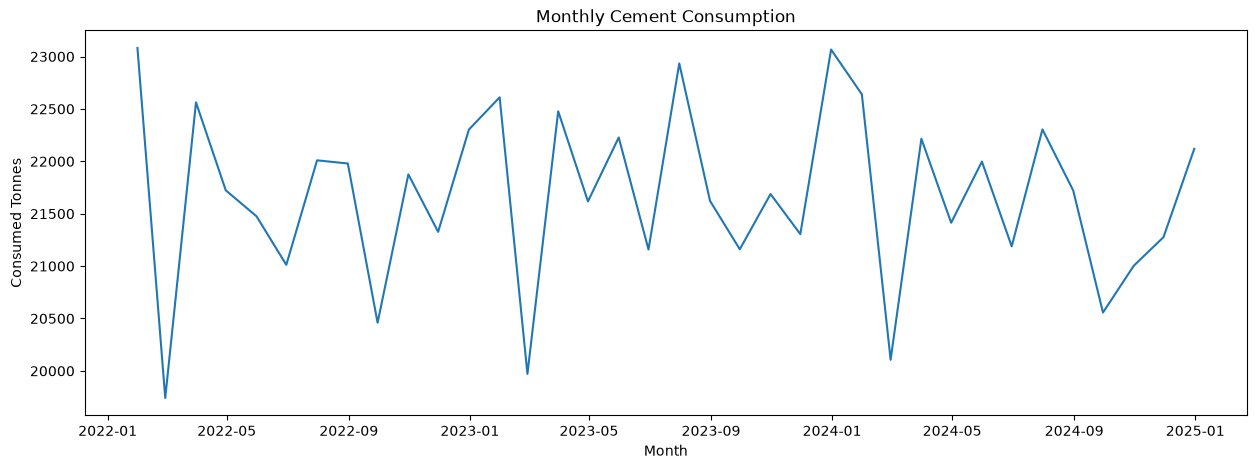

In [8]:
# ==========================================
# Monthly Cement Consumption
# ==========================================

monthly = (
    panel
    .set_index("date")
    .resample("M")["consumed_tonnes"]
    .sum()
)

plt.figure(figsize=(15,5))

plt.plot(monthly.index, monthly.values)

plt.title("Monthly Cement Consumption")

plt.xlabel("Month")
plt.ylabel("Consumed Tonnes")

plt.show()

Monthly consumption was analysed to smooth daily fluctuations and examine longer-term demand. The results indicate relatively stable monthly demand with moderate variations across the study period.

## Consumption by Region

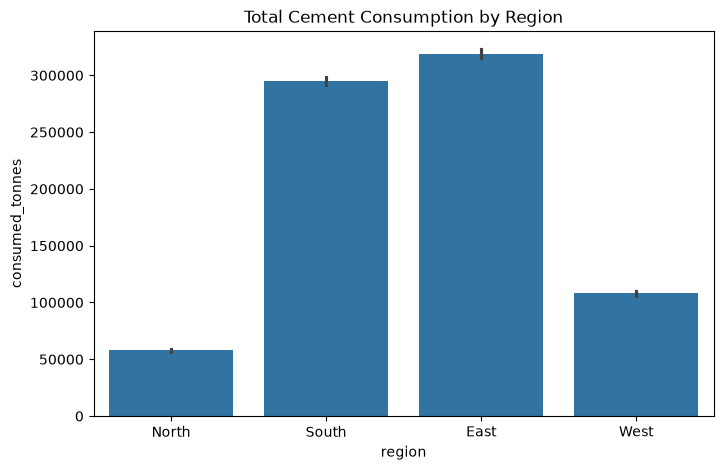

In [9]:
# ==========================================
# Cement Consumption by Region
# ==========================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=panel,
    x="region",
    y="consumed_tonnes",
    estimator="sum"
)

plt.title("Total Cement Consumption by Region")

plt.show()

Regional consumption was compared to identify geographical differences in demand. The East region recorded the highest total cement consumption, followed by the South, while the North and West contributed considerably lower demand.

## Consumption by Cement Type

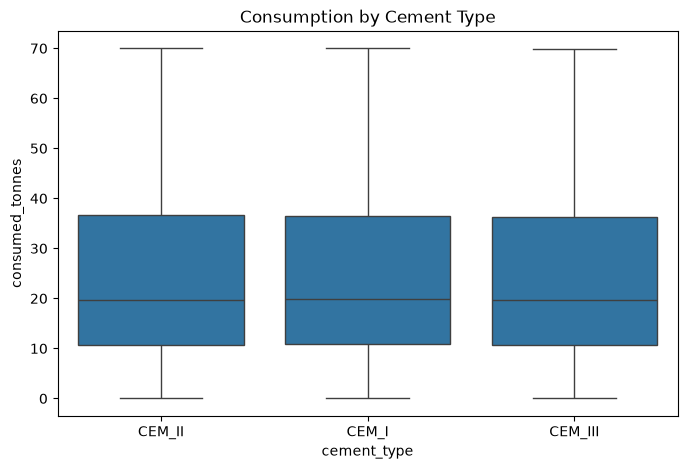

In [10]:
# ==========================================
# Cement Type Analysis
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=panel,
    x="cement_type",
    y="consumed_tonnes"
)

plt.title("Consumption by Cement Type")

plt.show()

Cement consumption was compared across the three cement types to identify differences in usage. The distributions are broadly similar, suggesting that demand patterns do not differ substantially between cement types.

## Weather Analysis

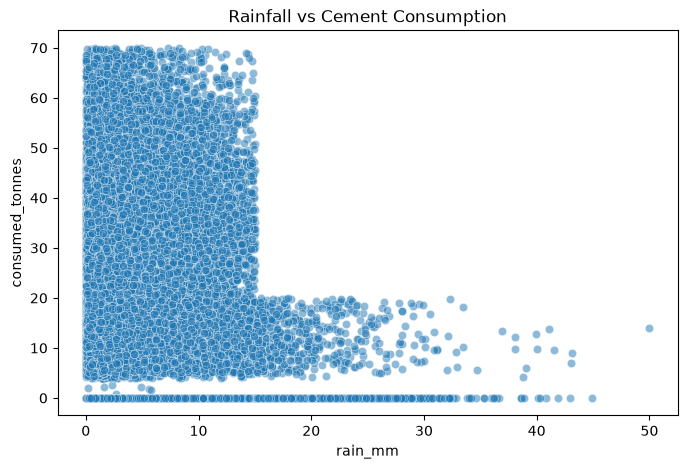

In [11]:
# ==========================================
# Rainfall vs Consumption
# ==========================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=panel,
    x="rain_mm",
    y="consumed_tonnes",
    alpha=0.5
)

plt.title("Rainfall vs Cement Consumption")

plt.show()

The relationship between rainfall and cement consumption was explored to assess the potential influence of weather. The scatter plot indicates a weak negative relationship, with higher rainfall generally associated with slightly lower cement consumption.

## Correlation Analysis

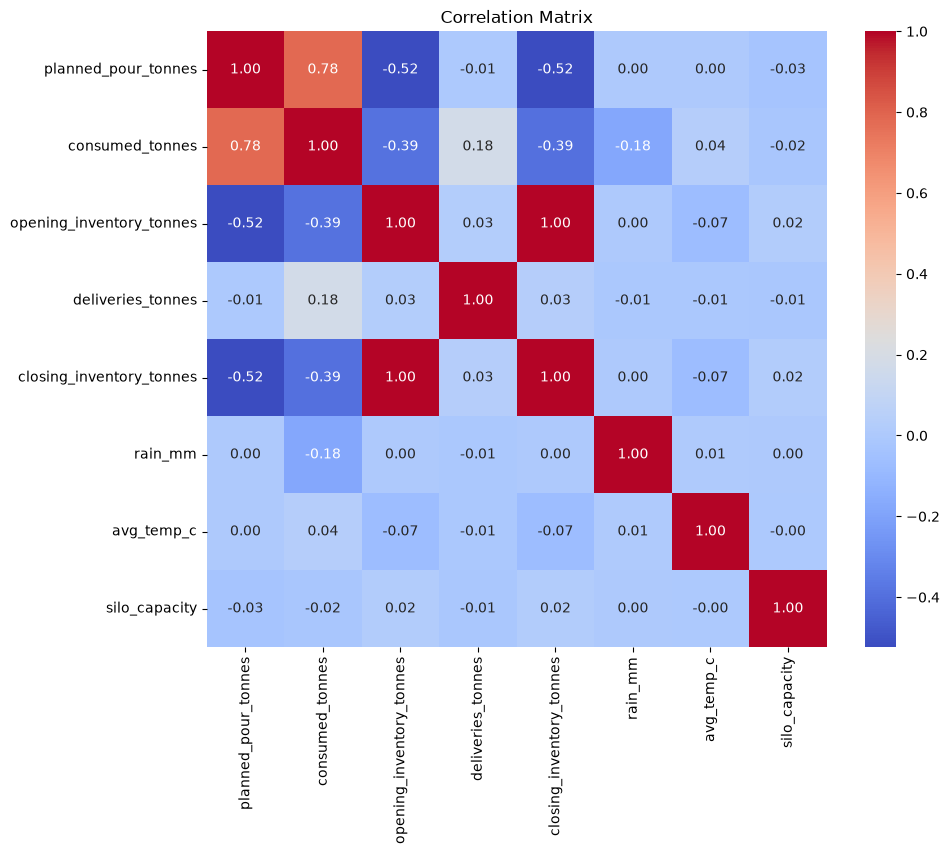

In [12]:
# ==========================================
# Correlation Matrix
# ==========================================

plt.figure(figsize=(10,8))

sns.heatmap(
    panel.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

Correlation analysis was performed to identify relationships between the numerical variables. Planned pour tonnage shows the strongest positive correlation with cement consumption (0.78), while rainfall exhibits a weak negative correlation (-0.18), indicating that operational factors are stronger predictors of demand than weather.

## Temperature Analysis

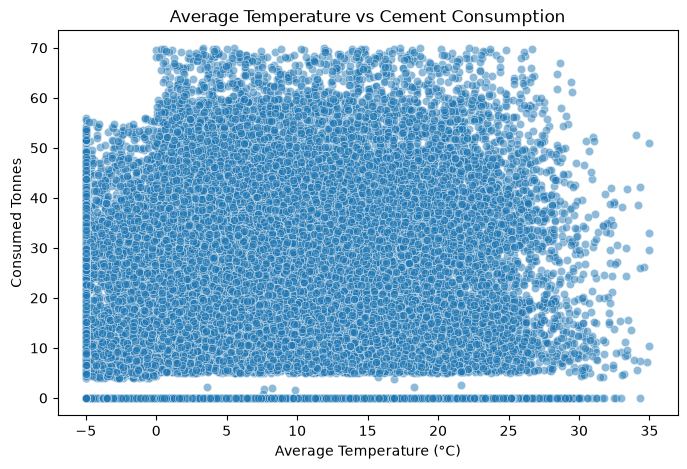

In [16]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=panel,
    x="avg_temp_c",
    y="consumed_tonnes",
    alpha=0.5
)

plt.title("Average Temperature vs Cement Consumption")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Consumed Tonnes")

plt.show()

he plot shows no clear linear relationship between temperature and cement consumption, with demand varying widely across most temperature ranges. This suggests that temperature alone may have limited predictive value for cement demand.

## Average Cement Consumption by Site

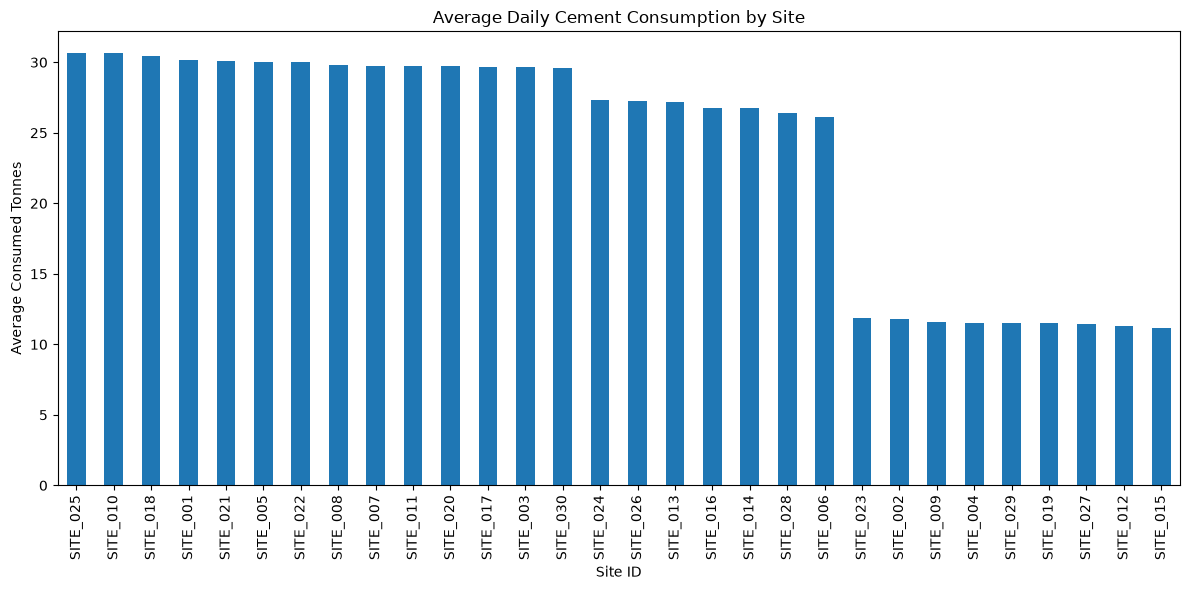

In [17]:
# ==========================================
# Average Cement Consumption by Site
# ==========================================

site_demand = (
    panel.groupby("site_id")["consumed_tonnes"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

site_demand.plot(kind="bar")

plt.title("Average Daily Cement Consumption by Site")
plt.xlabel("Site ID")
plt.ylabel("Average Consumed Tonnes")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Average daily cement consumption varies considerably across sites, with some sites recording around 30 tonnes per day while others average close to 11 tonnes. This indicates that site-level differences are important when forecasting cement demand.

## Monthly Seasonality Analysis

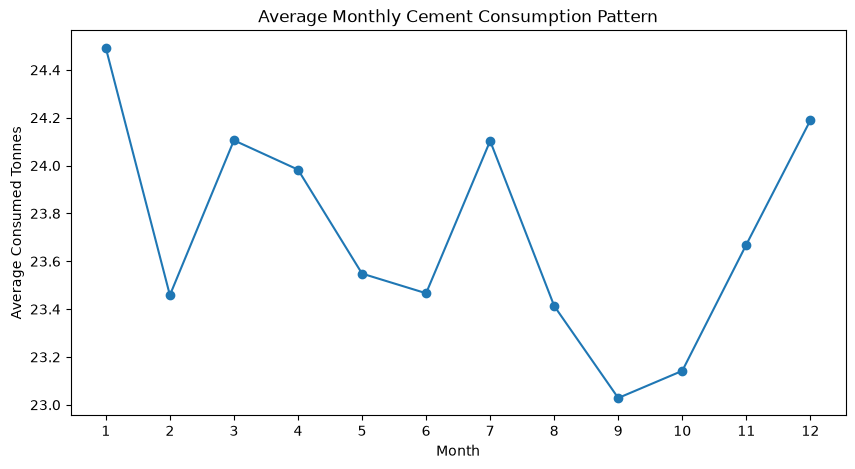

In [18]:
# ==========================================
# Monthly Seasonality Analysis
# ==========================================

panel["month"] = panel["date"].dt.month

monthly_seasonality = (
    panel.groupby("month")["consumed_tonnes"]
    .mean()
)

plt.figure(figsize=(10, 5))

monthly_seasonality.plot(marker="o")

plt.title("Average Monthly Cement Consumption Pattern")
plt.xlabel("Month")
plt.ylabel("Average Consumed Tonnes")

plt.xticks(range(1, 13))

plt.show()

Monthly consumption varies slightly throughout the year, with the highest average demand in January and the lowest in September. Overall, the variation is relatively small, suggesting no strong seasonal pattern.

## Key EDA Findings

Cement demand varies considerably across sites and regions, with the East region showing the highest total consumption and some sites averaging almost three times the daily consumption of lower-demand sites.

Planned pour tonnage is the strongest predictor identified in the correlation analysis, showing a strong positive relationship with actual cement consumption (r = 0.78).

Daily cement consumption fluctuates substantially, but the overall time series shows no clear long-term upward or downward trend. Monthly averages also vary only slightly, suggesting no strong seasonal pattern.

Inventory levels are highly uneven across sites, with a large difference between the mean and median values because a small number of sites maintain substantially higher inventory levels than the majority.

Rainfall shows a weak negative relationship with cement consumption (r = -0.18), while temperature shows little observable linear relationship with demand, suggesting that weather alone may have limited predictive value.

Consumption patterns are broadly similar across the three cement types, indicating that cement type may have less influence on overall demand than operational factors such as planned pours and site characteristics.

These findings suggest that future forecasting models should place greater emphasis on operational and site-level information, while considering weather variables as additional supporting predictors.

